# Dynamic v2 Sequence Classifier (dual-hand GRU, TFJS-native)

Trains a GRU that maps a 30-frame x 127-feature dual-hand sequence
(`[numHands, rightHandBlock(63), leftHandBlock(63)]` per frame — see
`landmark_features.py` / `frontend/src/lib/gesture/dual-hand-features.ts`)
to one of the recorded dynamic word classes. Architecture ported from the
"Kode Dynamic Kata" reference project's `src/training/model.py`
(`create_sequence_model`) with **one deliberate change**: `reset_after=False`
on the GRU layer. The reference's default (`reset_after=True`, Keras's
cuDNN-compatible variant) cannot be loaded by TFJS-layers
(`GRUCell does not support reset_after parameter set to true` — confirmed
during planning against the reference's own trained model). Setting it to
`False` here means the exported model loads natively via
`tf.loadLayersModel()` in the browser, with no hand-rolled GRU math needed.


In [1]:
import os
# Cap TF native threads BEFORE importing tf — improves stability on
# weaker CPUs. Required env vars are read only at first import.
os.environ.setdefault('TF_NUM_INTEROP_THREADS', '2')
os.environ.setdefault('TF_NUM_INTRAOP_THREADS', '4')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')  # silence INFO/WARN

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
SEQUENCE_LENGTH = 30  # must match SEQ_LENGTH in dual-hand-features.ts
FEATURE_DIM = 127  # must match FEATURE_DIM in dual-hand-features.ts
NPZ_PATH = 'data/gesture_sequences_v2.npz'
LABELS_CSV_PATH = 'dynamic_v2_labels.csv'
MODEL_PATH = 'dynamic_v2_classifier.keras'


In [2]:
data = np.load(NPZ_PATH, allow_pickle=True)
X = data['X'].astype(np.float32)
y = data['y'].astype(np.int32)
classes = [str(c) for c in data['classes'].tolist()]
NUM_CLASSES = len(classes)

assert X.shape[1:] == (SEQUENCE_LENGTH, FEATURE_DIM), f'Unexpected sample shape {X.shape[1:]}'
print(f'Loaded {len(X)} sequences, shape {X.shape}')
print(f'Classes ({NUM_CLASSES}): {classes}')
print('Per-class counts:', {c: int((y == i).sum()) for i, c in enumerate(classes)})

# Written for convert_to_tfjs.sh's write_labels step — same one-label-per-line
# format as the existing point_history_csv/dynamic_label.csv.
pd.Series(classes).to_csv(LABELS_CSV_PATH, index=False, header=False)
print(f'Wrote {LABELS_CSV_PATH}')


Loaded 41 sequences, shape (41, 30, 127)
Classes (2): ['seperti', 'yang']
Per-class counts: {'seperti': 21, 'yang': 20}
Wrote dynamic_v2_labels.csv


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y,
)
print(f'Train: {len(X_train)}, Validation: {len(X_val)}')


Train: 32, Validation: 9


In [4]:
# Upweight underrepresented classes — ported from the reference's
# compute_class_weights (train.py), useful if take counts per class end up
# uneven after a real recording session.
counts = np.bincount(y_train, minlength=NUM_CLASSES)
total = counts.sum()
class_weight = {
    i: float(total / (NUM_CLASSES * count)) if count > 0 else 1.0
    for i, count in enumerate(counts)
}
print('Class weights:', class_weight)


Class weights: {0: 1.0, 1: 1.0}


In [5]:
# GRU(64) -> Dropout -> Dense(32, relu) -> Dropout -> Dense(N, softmax).
# Ported from the reference's create_sequence_model, with reset_after=False
# added (see the notebook's title cell for why).
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(SEQUENCE_LENGTH, FEATURE_DIM)),
    tf.keras.layers.GRU(64, dropout=0.2, reset_after=False),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)
model.summary()


/home/arielsulton/Documents/Stargazing Project/VScode Project/tunarasa_ws/pensyarat/training/.venv/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,010 (152.38 KB)

 Trainable params: 39,010 (152.38 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1,
)
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1,
)
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', patience=5, factor=0.5, verbose=1,
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    class_weight=class_weight,
    callbacks=[cp_callback, es_callback, lr_callback],
    verbose=2,
)


Epoch 1/100



Epoch 1: val_loss improved from None to 0.69289, saving model to dynamic_v2_classifier.keras


2/2 - 5s - 2s/step - accuracy: 0.4375 - loss: 0.6787 - val_accuracy: 0.4444 - val_loss: 0.6929 - learning_rate: 0.0010


Epoch 2/100



Epoch 2: val_loss improved from 0.69289 to 0.69257, saving model to dynamic_v2_classifier.keras


...


Epoch 50: val_loss did not improve from 0.00004



Epoch 50: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.


2/2 - 0s - 100ms/step - accuracy: 1.0000 - loss: 2.0180e-04 - val_accuracy: 1.0000 - val_loss: 1.1446e-04 - learning_rate: 1.2500e-04


Epoch 50: early stopping


Restoring model weights from the end of the best epoch: 35.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step


              precision    recall  f1-score   support

     seperti      1.000     1.000     1.000         5
        yang      1.000     1.000     1.000         4

    accuracy                          1.000         9
   macro avg      1.000     1.000     1.000         9
weighted avg      1.000     1.000     1.000         9



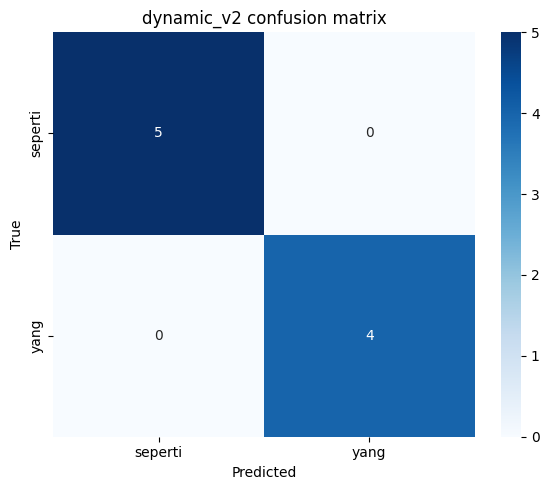

In [7]:
best_model = tf.keras.models.load_model(MODEL_PATH)
y_pred = np.argmax(best_model.predict(X_val), axis=1)

print(classification_report(y_val, y_pred, target_names=classes, digits=3))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('dynamic_v2 confusion matrix')
plt.tight_layout()
plt.savefig('dynamic_v2_confusion_matrix.png')
plt.show()


## Next step

Run `bash convert_to_tfjs.sh` (Task 8) to convert `dynamic_v2_classifier.keras`
+ `dynamic_v2_labels.csv` into `frontend/public/models/dynamic_v2/{model.json,
group1-shard1of1.bin,labels.json}`.
